## Codigo para pruebas de solo encoder para prediccion de elo

In [4]:
#El MAE te dirá "en promedio, el modelo se equivoca por X puntos de Elo"

import os
import io
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm  # Usa tqdm normal si ejecutas desde script .py, o tqdm.notebook si usas Jupyter
import chess
import chess.pgn
import joblib

# Imports de PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# --- FIJAR SEMILLAS PARA REPRODUCIBILIDAD EN PYTORCH ---
SEED = 37

random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)  # Para cuando usas múltiples GPUs
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

plt.ion()

In [5]:
# Verificación de aceleración por GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo activo: {device}")
if device.type == "cuda":
    print(f"GPU detectada: {torch.cuda.get_device_name(0)}")

Dispositivo activo: cuda
GPU detectada: NVIDIA GeForce RTX 4060 Laptop GPU


In [ ]:
class ChessDataset(Dataset):
    def __init__(self, npz_path, plies_a_usar=None, flatten=True, norm_type="standard"):
        datos = np.load(npz_path)

        X_completo = datos['X']
        plies_guardados = datos['plies_guardados'].tolist()
        
        if plies_a_usar is None:
            indices = list(range(len(plies_guardados)))
        else:
            indices = [plies_guardados.index(p) for p in plies_a_usar]
            
        X_filtrado = X_completo[:, indices, :]
        
        if flatten:
            X_filtrado = X_filtrado.reshape(X_filtrado.shape[0], -1)
            
        self.X = torch.tensor(X_filtrado, dtype=torch.float32)
        
        if norm_type == "minmax":
            y_seleccionada = datos['y_minmax']
        elif norm_type == "robust":
            y_seleccionada = datos['y_robust']
        elif norm_type == "raw":
            y_seleccionada = datos['y_raw']
        else:
            y_seleccionada = datos['y_standard'] # Por defecto
            
        # Lo pasamos a tensor y le damos forma (N, 1)
        self.y = torch.tensor(y_seleccionada, dtype=torch.float32).view(-1, 1)
        
        self.input_dim = self.X.shape[1] if flatten else self.X.shape[2]

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [70]:
plies = [20] # [15,16,17,18,20,21,22,23,30,31,32,33,40,41,42,43]
ply = 20
flatten = 1
norm = "robust" # "standard", "minmax", "robust"
print("Cargando datasets a la memoria...")

train_ds = ChessDataset("../data/generado/only_enc/train.npz", plies_a_usar=plies, flatten=flatten, norm_type=norm)
val_ds = ChessDataset("../data/generado/only_enc/val.npz", plies_a_usar=plies, flatten=flatten, norm_type=norm)
test_ds = ChessDataset("../data/generado/only_enc/test.npz", plies_a_usar=plies, flatten=flatten, norm_type=norm)

# El DataLoader se encarga de crear los batches y hacer el shuffle usando C++ internamente
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

Cargando datasets a la memoria...


In [71]:
encoder_salida = f"../data/encoders/only_enc/pesos_norm_{norm}_ply_{ply}.npy"
pred_salida = f"../data/predict/norm_{norm}_ply_{ply}.npy"

In [72]:
class ChessEncoder(nn.Module):
    def __init__(self, input_dim):
        super(ChessEncoder, self).__init__()
        self.red = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Linear(32, 1) # Salida: 1 valor de Elo
        )

    def forward(self, x):
        return self.red(x)

In [73]:
modelo = ChessEncoder(input_dim=train_ds.X.shape[1]).to(device)
optimizador = torch.optim.Adam(modelo.parameters(), lr=1e-3)
criterio = nn.MSELoss()

In [74]:
# --- BUCLE DE ENTRENAMIENTO ---
epocas = 50
paciencia = 3
mejor_val_loss = float('inf')
epocas_sin_mejora = 0

for epoca in range(epocas):
    # Fase de Entrenamiento
    modelo.train()
    train_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizador.zero_grad()           # 1. Limpiar gradientes viejos
        predicciones = modelo(batch_X)    # 2. Predecir
        loss = criterio(predicciones, batch_y) # 3. Calcular el error
        loss.backward()                   # 4. Propagar el error hacia atrás (Backprop)
        optimizador.step()                # 5. Actualizar los pesos
        
        train_loss += loss.item() * batch_X.size(0)
    
    # Fase de Validación
    modelo.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            predicciones = modelo(batch_X)
            loss = criterio(predicciones, batch_y)
            val_loss += loss.item() * batch_X.size(0)
            
    # Promedios de la época
    train_loss /= len(train_loader.dataset)
    val_loss /= len(val_loader.dataset)
    print(f"Época {epoca+1}/{epocas} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    # --- EARLY STOPPING ---
    if val_loss < mejor_val_loss:
        mejor_val_loss = val_loss
        epocas_sin_mejora = 0
        
        # 1. Empaquetamos los pesos y los metadatos del experimento
        checkpoint = {
            'input_dim': train_ds.input_dim,
            'arquitectura': 'Dense_512_256_128_32',
            'epoca_optima': epoca + 1,
            'estado_pesos': modelo.state_dict()
        }
        
        # 2. Guardo el archivo
        torch.save(checkpoint, encoder_salida) 
        
    else:
        epocas_sin_mejora += 1
        if epocas_sin_mejora >= paciencia:
            print(f"\nEarly stopping activado. El modelo no mejoró en {paciencia} épocas.")
            print(f"Recuperando los mejores pesos de la época {epoca + 1 - paciencia}...")
            
            # 3. Cargamos el archivo completo a la RAM
            checkpoint_recuperado = torch.load(encoder_salida)
            
            modelo.load_state_dict(checkpoint_recuperado['estado_pesos'])

            break

Época 1/50 | Train Loss: 0.3729 | Val Loss: 0.3619
Época 2/50 | Train Loss: 0.3380 | Val Loss: 0.3348
Época 3/50 | Train Loss: 0.3188 | Val Loss: 0.3334
Época 4/50 | Train Loss: 0.3047 | Val Loss: 0.3374
Época 5/50 | Train Loss: 0.2914 | Val Loss: 0.3367
Época 6/50 | Train Loss: 0.2760 | Val Loss: 0.3408

Early stopping activado. El modelo no mejoró en 3 épocas.
Recuperando los mejores pesos de la época 3...


C:\Users\agust\AppData\Local\Temp\ipykernel_4412\1058036001.py:60: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint_recuperado = torch.load(encoder_salida)


In [75]:
ELO_MIN = 900
ELO_MAX = 2750
ELO_MEAN = 1551.1 
ELO_STD = 299.6  
ELO_MEDIAN = 1548.0
ELO_Q1 = 1332.0
ELO_Q3 = 1763.0
ELO_IQR = ELO_Q3 - ELO_Q1

In [76]:
def desnormalizar_elo(elo_norm, metodo):
    """Convierte el Elo normalizado de vuelta a puntos de Elo reales."""
    if metodo == "minmax":
        return elo_norm * (ELO_MAX - ELO_MIN) + ELO_MIN
    elif metodo == "standard":
        return elo_norm * ELO_STD + ELO_MEAN
    elif metodo == "robust":
        return elo_norm * ELO_IQR + ELO_MEDIAN
    else:
        return elo_norm

In [77]:
modelo.eval() # Modo evaluación
y_true_list = []
y_pred_list = []

print("Calculando predicciones en el Test set...")
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        
        # Predecir
        predicciones = modelo(batch_X)
        
        # Mover a la CPU, convertir a numpy y guardar en la lista
        y_pred_list.extend(predicciones.cpu().numpy().flatten())
        y_true_list.extend(batch_y.numpy().flatten())

# --- 4. DESNORMALIZAR ---
y_true_real = desnormalizar_elo(np.array(y_true_list), norm)
y_pred_real = desnormalizar_elo(np.array(y_pred_list), norm)
np.save(pred_salida, y_pred_real)


Calculando predicciones en el Test set...


In [78]:
errores_absolutos = np.abs(y_true_real - y_pred_real)
errores_cuadraticos = (y_true_real - y_pred_real) ** 2

# 2. Calculamos las métricas globales
mae = np.mean(errores_absolutos)
mse = np.mean(errores_cuadraticos)
rmse = np.sqrt(mse)

# 3. Métricas extra útiles para la tesis
error_mediano = np.median(errores_absolutos)
max_error = np.max(errores_absolutos)

print("--- RESULTADOS FINALES DE LA TESIS ---")
print(f"MAE (Error Absoluto Medio):   {mae:.1f} puntos de Elo")
print(f"Mediana del Error:            {error_mediano:.1f} puntos de Elo")
print(f"RMSE (Raíz Error Cuadrático): {rmse:.1f} puntos de Elo")
print(f"Peor equivocación del modelo: {max_error:.1f} puntos de Elo")

--- RESULTADOS FINALES DE LA TESIS ---
MAE (Error Absoluto Medio):   202.3 puntos de Elo
Mediana del Error:            169.6 puntos de Elo
RMSE (Raíz Error Cuadrático): 254.7 puntos de Elo
Peor equivocación del modelo: 1236.7 puntos de Elo


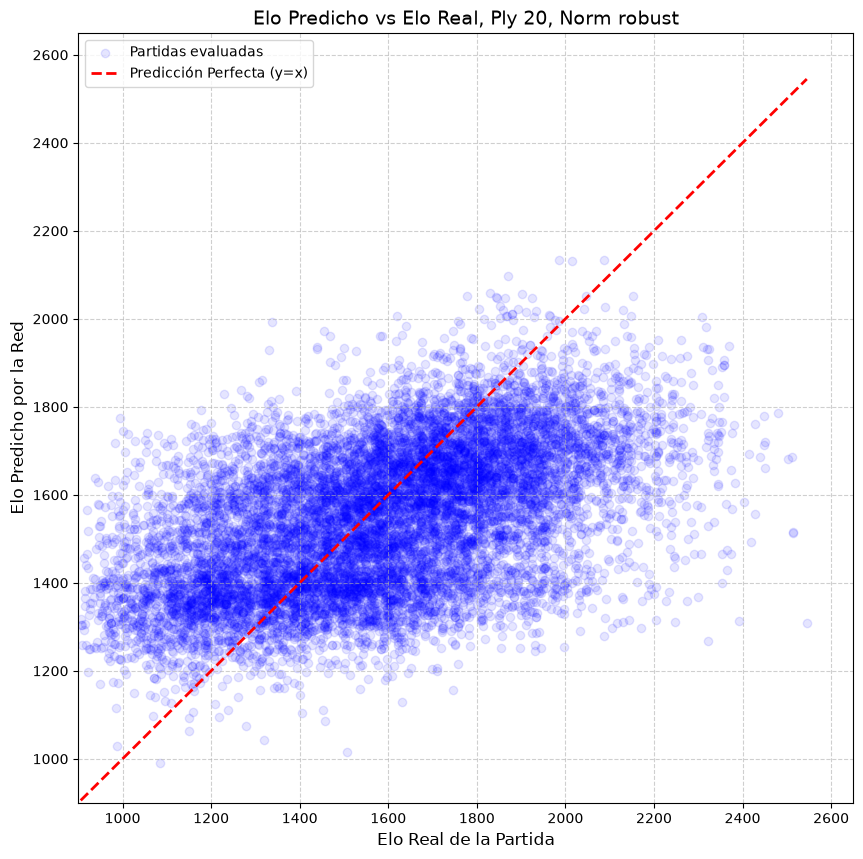

In [79]:
plt.figure(figsize=(10, 10))

plt.scatter(y_true_real, y_pred_real, alpha=0.1, color='blue', label='Partidas evaluadas')

min_val = min(min(y_true_real), min(y_pred_real))
max_val = max(max(y_true_real), max(y_pred_real))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Predicción Perfecta (y=x)')

plt.title(f'Elo Predicho vs Elo Real, Ply {ply}, Norm {norm}', fontsize=14)
plt.xlabel('Elo Real de la Partida', fontsize=12)
plt.ylabel('Elo Predicho por la Red', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Limitar los ejes a valores lógicos del ajedrez (ej. 800 a 3000)
plt.xlim(ELO_MIN, ELO_MAX-100)
plt.ylim(ELO_MIN, ELO_MAX-100)

plt.show()